# 03 — Parameter sensitivity analysis

Publication version using the frozen derived regional model input.


In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate publication repository root.")

project_root = find_project_root()
src_dir = project_root / "src"

if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from model_config import baseline_params, teredo_k, alpha_rate
from decay_model import (
    compute_total_decay_full,
    compute_steel_reference,
    build_rate_scale,
)

print("Project root:", project_root)


Project root: /media/syms/ExtremeSSD/ShipwreckENDURE_Publication


## 1. Load the production regional dataset

The dataset is loaded into memory inside a context manager and the file handle is closed immediately. This avoids locking `ABMsubset.nc` if Notebook 02 needs to rebuild it later.


In [2]:
data_dir = project_root / "data"
out_dir = project_root / "outputs" / "figure_data"
out_dir.mkdir(parents=True, exist_ok=True)

regional_ds_path = data_dir / "model_inputs" / "publication_model_inputs.nc"

if not regional_ds_path.exists():
    raise FileNotFoundError(
        f"Missing publication model input: {regional_ds_path}. "
        "Run 00_prepare_publication_data.ipynb first."
    )

with xr.open_dataset(regional_ds_path) as ds:
    ABMsubset = ds.load()

if ABMsubset.latitude.values[0] > ABMsubset.latitude.values[-1]:
    ABMsubset = ABMsubset.sortby("latitude")

print("Regional dataset:", regional_ds_path)
print("Dimensions:", dict(ABMsubset.sizes))
print("Variables:", len(ABMsubset.data_vars))


Regional dataset: /media/syms/ExtremeSSD/ShipwreckENDURE_Publication/data/model_inputs/publication_model_inputs.nc
Dimensions: {'latitude': 61, 'longitude': 236}
Variables: 24


The publication repository consumes the frozen derived model input directly.
The development-only step that rebuilt `ABMsubset.nc` from the much larger regional
archive has intentionally been removed.


## 2. Production wave-field verification

The preferred production wave descriptor is `seabed_orbital_velocity_mean`, derived from the original three-hourly wave archive **before** temporal averaging. The decay engine should consume this field directly.

This check fails loudly if the rebuilt regional dataset does not contain the corrected descriptor.


In [3]:
required_wave_var = "seabed_orbital_velocity_mean"

if required_wave_var not in ABMsubset:
    raise KeyError(
        f"{required_wave_var!r} not found in ABMsubset.nc. "
        "Re-run 00_prepare_publication_data.ipynb before sensitivity analysis."
    )

x = ABMsubset[required_wave_var].values
x = x[np.isfinite(x)]

print(pd.Series(x).describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
))


count    9.823000e+03
mean     1.440442e-02
std      2.710680e-02
min      1.029140e-17
50%      4.659795e-03
75%      1.520281e-02
90%      3.896728e-02
95%      6.189164e-02
99%      1.432040e-01
max      2.848611e-01
dtype: float64


## 3. Baseline production model

The baseline configuration comes only from `model_config.py`. The sensitivity notebook does not maintain its own alternative baseline.


In [4]:
params0 = baseline_params.copy()

print("Baseline parameters:")
for key, value in params0.items():
    print(f"  {key}: {value}")

print("\nTeredo settings:", teredo_k)
print("alpha_rate:", alpha_rate)

steel_ref, steel_ref_ref = compute_steel_reference(
    ABMsubset.copy(),
    params0,
)

print("\nSteel reference:", steel_ref_ref)


Baseline parameters:
  Ea: 50000.0
  U_ref: 0.3
  K_O2: 30.0
  S_mid_corr: 12.0
  S_steep_corr: 6.0
  burial_alpha: 0.7
  burial_strength: 0.5

Teredo settings: {'none': 0.0, 'low': 0.02, 'medium': 0.1, 'high': 0.5}
alpha_rate: 0.7

Steel reference: 0.0007340469652168743


In [5]:
# Verify that decay_model.py is consuming the corrected stored wave field.
production_check = compute_total_decay_full(
    ABMsubset.copy(),
    wreck_material="steel",
    k_teredo=0.0,
    **params0,
)

same_wave_field = np.allclose(
    production_check["orbital_velocity"].values,
    ABMsubset["seabed_orbital_velocity_mean"].values,
    equal_nan=True,
)

print("Decay engine uses corrected stored orbital-velocity field:", same_wave_field)

if not same_wave_field:
    raise RuntimeError(
        "Production decay engine is not consuming "
        "'seabed_orbital_velocity_mean' as expected."
    )


Decay engine uses corrected stored orbital-velocity field: True


## 4. Sensitivity helpers

Sensitivity is evaluated as the ratio of the tested `rate_scale` to the baseline `rate_scale` for the same material/scenario. Cell-level ratios are subsampled only for plotting/distribution products; the summary statistics use all valid cells.


In [6]:
def run_scenario(material, teredo="none", params=None, k_override=None):
    params = params0.copy() if params is None else params.copy()

    k = teredo_k[teredo] if k_override is None else k_override
    use_teredo = (teredo != "none") and (material in ("wood", "mixed"))

    ds = compute_total_decay_full(
        ABMsubset.copy(),
        wreck_material=material,
        k_teredo=k,
        **params,
    )

    CR_total, rate_scale = build_rate_scale(
        ds,
        material=material,
        use_teredo=use_teredo,
        steel_ref_ref=steel_ref_ref,
        alpha=alpha_rate,
    )

    return ds, CR_total, rate_scale


def summarise_ratio(test_rate, base_rate, parameter, value, scenario):
    ratio = (test_rate / base_rate).values
    ratio = ratio[np.isfinite(ratio)].ravel()

    return {
        "parameter": parameter,
        "value": value,
        "scenario": scenario,
        "median_ratio": np.nanmedian(ratio),
        "p05_ratio": np.nanpercentile(ratio, 5),
        "p25_ratio": np.nanpercentile(ratio, 25),
        "p75_ratio": np.nanpercentile(ratio, 75),
        "p95_ratio": np.nanpercentile(ratio, 95),
        "min_ratio": np.nanmin(ratio),
        "max_ratio": np.nanmax(ratio),
    }


def sample_cell_ratios(
    test_rate,
    base_rate,
    parameter,
    value,
    scenario,
    max_cells=5000,
    seed=123,
):
    ratio = (test_rate / base_rate).values
    ratio = ratio[np.isfinite(ratio)].ravel()

    if ratio.size > max_cells:
        rng = np.random.default_rng(seed)
        ratio = rng.choice(ratio, size=max_cells, replace=False)

    return pd.DataFrame({
        "parameter": parameter,
        "value": value,
        "scenario": scenario,
        "ratio": ratio,
    })


## 5. One-at-a-time sensitivity plan

- Corrosion and mechanical-forcing parameters: steel, no Teredo.
- Burial parameters: wood, no Teredo.
- Teredo intensity: wood, high-Teredo scenario.

Current and wave reference scales are varied independently. `U_ref = 0.30 m s⁻¹` remains the production baseline at this stage; separate `U_current_ref` and `U_wave_ref` values are sensitivity perturbations, not new baseline calibration.


In [7]:
sensitivity_plan = [
    {
        "parameter": "Ea",
        "values": [30000.0, 40000.0, 50000.0, 60000.0, 70000.0],
        "scenario": ("steel", "none"),
    },
    {
        "parameter": "U_current_ref",
        "values": [0.15, 0.30, 0.60],
        "scenario": ("steel", "none"),
    },
    {
        "parameter": "U_wave_ref",
        "values": [0.15, 0.30, 0.60],
        "scenario": ("steel", "none"),
    },
    {
        "parameter": "hydro_interaction_strength",
        "values": [0.0, 0.10, 0.25, 0.50, 1.00],
        "scenario": ("steel", "none"),
    },
    {
        "parameter": "S_mid_corr",
        "values": [8.0, 10.0, 12.0, 14.0, 16.0],
        "scenario": ("steel", "none"),
    },
    {
        "parameter": "burial_alpha",
        "values": [0.4, 0.7, 1.0, 1.3],
        "scenario": ("wood", "none"),
    },
    {
        "parameter": "burial_strength",
        "values": [0.25, 0.50, 0.75, 1.0],
        "scenario": ("wood", "none"),
    },
]


In [8]:
baseline_rates = {}

for material, teredo in [
    ("steel", "none"),
    ("wood", "none"),
    ("wood", "high"),
    ("mixed", "high"),
]:
    _, _, rate = run_scenario(material, teredo)
    baseline_rates[f"{material}_{teredo}"] = rate

summary_rows = []
cell_frames = []

for item in sensitivity_plan:
    parameter = item["parameter"]
    material, teredo = item["scenario"]
    scenario = f"{material}_{teredo}"
    base_rate = baseline_rates[scenario]

    for value in item["values"]:
        params = params0.copy()
        params[parameter] = value

        _, _, test_rate = run_scenario(
            material,
            teredo,
            params=params,
        )

        summary_rows.append(
            summarise_ratio(
                test_rate,
                base_rate,
                parameter,
                value,
                scenario,
            )
        )

        cell_frames.append(
            sample_cell_ratios(
                test_rate,
                base_rate,
                parameter,
                value,
                scenario,
            )
        )

sens_df = pd.DataFrame(summary_rows)
sens_df


,parameter,value,scenario,median_ratio,p05_ratio,p25_ratio,p75_ratio,p95_ratio,min_ratio,max_ratio
0,Ea,30000.00,steel_none,1.257924,1.146768,1.199163,1.406748,1.485426,1.113256,1.530306
1,Ea,40000.00,steel_none,1.124238,1.072423,1.097294,1.189141,1.221443,1.056162,1.239296
2,Ea,50000.00,steel_none,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,Ea,60000.00,steel_none,0.885497,0.815658,0.837352,0.907700,0.929715,0.804463,0.944858
4,Ea,70000.00,steel_none,0.780468,0.663135,0.698701,0.820481,0.861765,0.645532,0.890830
5,U_current_ref,0.15,steel_none,1.361328,1.112154,1.250680,1.525046,1.731486,1.000000,1.794836
6,U_current_ref,0.30,steel_none,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,U_current_ref,0.60,steel_none,0.758869,0.605083,0.693201,0.854725,1.000000,0.555374,1.000000
8,U_wave_ref,0.15,steel_none,1.066967,1.000000,1.001479,1.148439,1.251848,1.000000,1.565632
9,U_wave_ref,0.30,steel_none,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 6. Teredo intensity sensitivity

In [9]:
teredo_rows = []

material = "wood"
teredo = "high"
scenario = "wood_high"
base_rate = baseline_rates[scenario]

for k in [0.10, 0.20, 0.50, 1.00]:
    _, _, test_rate = run_scenario(
        material,
        teredo,
        params=params0,
        k_override=k,
    )

    teredo_rows.append(
        summarise_ratio(
            test_rate,
            base_rate,
            "k_teredo_high",
            k,
            scenario,
        )
    )

    cell_frames.append(
        sample_cell_ratios(
            test_rate,
            base_rate,
            "k_teredo_high",
            k,
            scenario,
        )
    )

teredo_df = pd.DataFrame(teredo_rows)
sens_all = pd.concat([sens_df, teredo_df], ignore_index=True)
cell_ratio_df = pd.concat(cell_frames, ignore_index=True)

sens_all


,parameter,value,scenario,median_ratio,p05_ratio,p25_ratio,p75_ratio,p95_ratio,min_ratio,max_ratio
0,Ea,30000.00,steel_none,1.257924,1.146768,1.199163,1.406748,1.485426,1.113256,1.530306
1,Ea,40000.00,steel_none,1.124238,1.072423,1.097294,1.189141,1.221443,1.056162,1.239296
2,Ea,50000.00,steel_none,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,Ea,60000.00,steel_none,0.885497,0.815658,0.837352,0.907700,0.929715,0.804463,0.944858
4,Ea,70000.00,steel_none,0.780468,0.663135,0.698701,0.820481,0.861765,0.645532,0.890830
5,U_current_ref,0.15,steel_none,1.361328,1.112154,1.250680,1.525046,1.731486,1.000000,1.794836
6,U_current_ref,0.30,steel_none,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
7,U_current_ref,0.60,steel_none,0.758869,0.605083,0.693201,0.854725,1.000000,0.555374,1.000000
8,U_wave_ref,0.15,steel_none,1.066967,1.000000,1.001479,1.148439,1.251848,1.000000,1.565632
9,U_wave_ref,0.30,steel_none,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 7. Export manuscript sensitivity products

In [10]:
summary_file = out_dir / "supp_sensitivity_full_summary.csv"
cell_file = out_dir / "supp_sensitivity_cell_ratios.csv"

sens_all.to_csv(summary_file, index=False)
cell_ratio_df.to_csv(cell_file, index=False)

tornado_df = (
    sens_all
    .groupby(["parameter", "scenario"], as_index=False)
    .agg(
        low=("median_ratio", "min"),
        high=("median_ratio", "max"),
        p05_low=("p05_ratio", "min"),
        p95_high=("p95_ratio", "max"),
    )
)

tornado_file = out_dir / "fig5_tornado_summary.csv"
tornado_df.to_csv(tornado_file, index=False)

print("Saved:", summary_file)
print("Saved:", cell_file)
print("Saved:", tornado_file)

tornado_df.sort_values(["low", "high"])


Saved: /media/syms/ExtremeSSD/ShipwreckENDURE_Publication/outputs/figure_data/supp_sensitivity_full_summary.csv
Saved: /media/syms/ExtremeSSD/ShipwreckENDURE_Publication/outputs/figure_data/supp_sensitivity_cell_ratios.csv
Saved: /media/syms/ExtremeSSD/ShipwreckENDURE_Publication/outputs/figure_data/fig5_tornado_summary.csv


,parameter,scenario,low,high,p05_low,p95_high
7,k_teredo_high,wood_high,0.739956,1.176783,0.658219,1.242924
2,U_current_ref,steel_none,0.758869,1.361328,0.605083,1.731486
0,Ea,steel_none,0.780468,1.257924,0.663135,1.485426
5,burial_strength,wood_none,0.879187,1.086097,0.531093,1.209199
3,U_wave_ref,steel_none,0.965037,1.066967,0.825072,1.251848
4,burial_alpha,wood_none,0.967073,1.056887,0.918420,1.094941
1,S_mid_corr,steel_none,0.978304,1.011598,0.686069,1.369349
6,hydro_interaction_strength,steel_none,1.000000,1.000986,1.000000,1.015230


## 8. Mechanical-forcing diagnostics

These diagnostics describe the production mechanical field after the wave-preprocessing correction. They are interpretation checks, not additional model fitting.


In [11]:
steel_ds = production_check

def describe_da(name, da):
    x = da.values
    x = x[np.isfinite(x)].ravel()

    print(f"\n{name}")
    print(pd.Series(x).describe(
        percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
    ))

for name in [
    "current_speed_mean",
    "orbital_velocity",
    "fCurrent",
    "fWave",
    "fHydro",
]:
    if name in steel_ds:
        describe_da(name, steel_ds[name])

interaction_product = steel_ds["fCurrent"] * steel_ds["fWave"]
describe_da("fCurrent × fWave", interaction_product)

fc = steel_ds["fCurrent"].values.ravel()
fw = steel_ds["fWave"].values.ravel()
ok = np.isfinite(fc) & np.isfinite(fw)

print(
    "\nCorrelation fCurrent vs fWave:",
    np.corrcoef(fc[ok], fw[ok])[0, 1],
)
print(
    "Cells with both fCurrent > 0.5 and fWave > 0.5:",
    np.mean((fc[ok] > 0.5) & (fw[ok] > 0.5)),
)



current_speed_mean
count    9863.000000
mean        0.047324
std         0.043184
min         0.002153
1%          0.007115
5%          0.011252
25%         0.020790
50%         0.033690
75%         0.056709
95%         0.133975
99%         0.235260
max         0.414231
dtype: float64

orbital_velocity
count    9.823000e+03
mean     1.440442e-02
std      2.710680e-02
min      1.029140e-17
1%       3.112082e-11
5%       1.756459e-07
25%      1.579141e-04
50%      4.659795e-03
75%      1.520281e-02
95%      6.189164e-02
99%      1.432040e-01
max      2.848611e-01
dtype: float64

fCurrent
count    9863.000000
mean        0.125726
std         0.086288
min         0.007126
1%          0.023169
5%          0.036151
25%         0.064808
50%         0.100962
75%         0.158978
95%         0.308715
99%         0.439525
max         0.579968
dtype: float64

fWave
count    9.823000e+03
mean     4.030350e-02
std      6.475537e-02
min      3.430468e-17
1%       1.037361e-10
5%       5.854860e-07


In [12]:
depth = steel_ds["deptho_mean"].values.ravel()
wave = steel_ds["orbital_velocity"].values.ravel()
current = steel_ds["current_speed_mean"].values.ravel()

ok = np.isfinite(depth) & np.isfinite(wave) & np.isfinite(current)

forcing_by_depth = pd.DataFrame({
    "depth_m": depth[ok],
    "wave": wave[ok],
    "current": current[ok],
})

forcing_by_depth["depth_band"] = pd.cut(
    forcing_by_depth["depth_m"],
    bins=[0, 10, 20, 30, 40, 50, 75, 100, 200, np.inf],
    right=False,
)

depth_summary = (
    forcing_by_depth
    .groupby("depth_band", observed=True)
    .agg(
        n=("wave", "size"),
        wave_median=("wave", "median"),
        wave_p95=("wave", lambda x: np.nanpercentile(x, 95)),
        current_median=("current", "median"),
        current_p95=("current", lambda x: np.nanpercentile(x, 95)),
    )
)

depth_summary


,n,wave_median,wave_p95,current_median,current_p95
depth_band,,,,,
"[0.0, 10.0)",759,2.931275e-02,0.167700,0.049598,0.109671
"[10.0, 20.0)",1091,2.125646e-02,0.138222,0.047300,0.126351
"[20.0, 30.0)",1064,2.276093e-02,0.065800,0.041234,0.138005
"[30.0, 40.0)",1240,1.298368e-02,0.031961,0.037648,0.100660
"[40.0, 50.0)",1288,7.822428e-03,0.016187,0.028434,0.091472
"[50.0, 75.0)",1697,2.469049e-03,0.008673,0.024714,0.127705
"[75.0, 100.0)",952,4.431335e-05,0.002407,0.023264,0.150520
"[100.0, 200.0)",1070,2.767133e-06,0.000614,0.019043,0.168019
"[200.0, inf)",662,1.394283e-07,0.000928,0.042347,0.099215


In [13]:
# Diagnostic overlap thresholds only — these are NOT model parameters.
for wave_thr in [0.01, 0.02, 0.05]:
    for current_thr in [0.03, 0.05, 0.10]:
        frac = np.mean(
            (forcing_by_depth["wave"] >= wave_thr)
            & (forcing_by_depth["current"] >= current_thr)
        )

        print(
            f"wave >= {wave_thr:.2f}, "
            f"current >= {current_thr:.2f}: "
            f"{100 * frac:.1f}%"
        )


wave >= 0.01, current >= 0.03: 26.4%
wave >= 0.01, current >= 0.05: 14.3%
wave >= 0.01, current >= 0.10: 2.9%
wave >= 0.02, current >= 0.03: 15.9%
wave >= 0.02, current >= 0.05: 9.3%
wave >= 0.02, current >= 0.10: 2.0%
wave >= 0.05, current >= 0.03: 6.0%
wave >= 0.05, current >= 0.05: 3.5%
wave >= 0.05, current >= 0.10: 0.8%


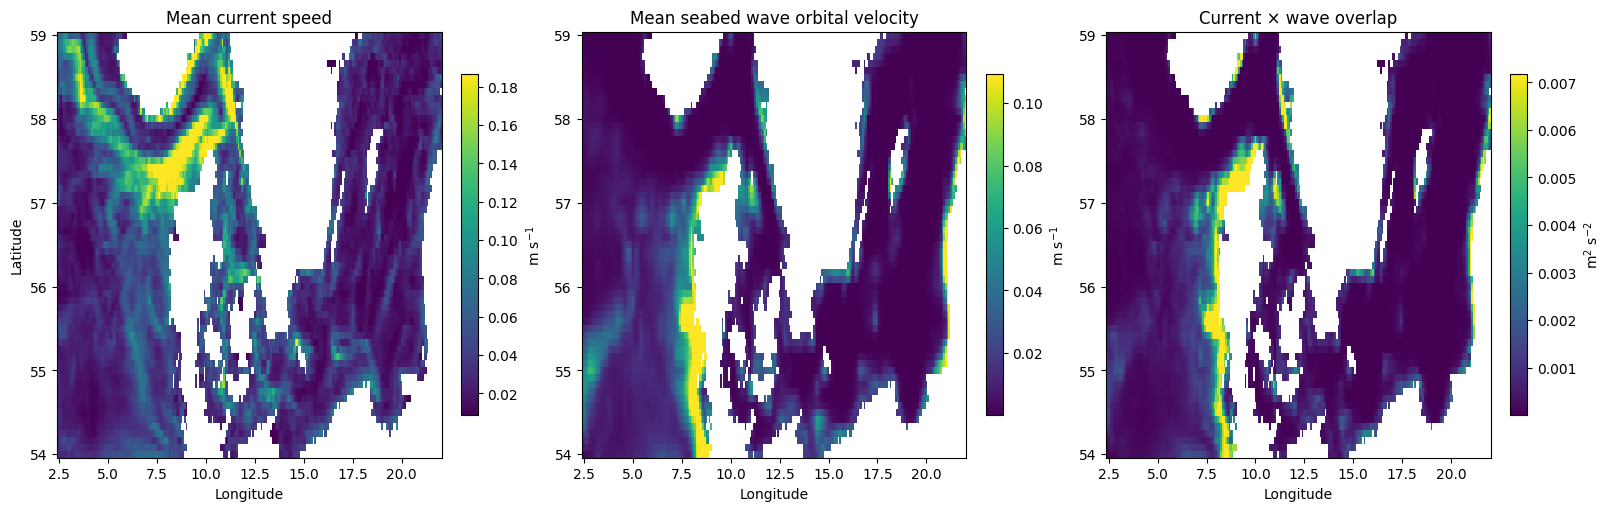

In [14]:
# Compact spatial reality check.
current_map = steel_ds["current_speed_mean"]
wave_map = steel_ds["orbital_velocity"]
overlap_map = current_map * wave_map

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    constrained_layout=True,
)

p0 = current_map.plot(
    ax=axes[0],
    robust=True,
    add_colorbar=False,
)
axes[0].set_title("Mean current speed")
cb0 = fig.colorbar(p0, ax=axes[0], shrink=0.8)
cb0.set_label("m s$^{-1}$")

p1 = wave_map.plot(
    ax=axes[1],
    robust=True,
    add_colorbar=False,
)
axes[1].set_title("Mean seabed wave orbital velocity")
cb1 = fig.colorbar(p1, ax=axes[1], shrink=0.8)
cb1.set_label("m s$^{-1}$")

p2 = overlap_map.plot(
    ax=axes[2],
    robust=True,
    add_colorbar=False,
)
axes[2].set_title("Current × wave overlap")
cb2 = fig.colorbar(p2, ax=axes[2], shrink=0.8)
cb2.set_label("m$^2$ s$^{-2}$")

for ax in axes:
    ax.set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[1].set_ylabel("")
axes[2].set_ylabel("")

plt.show()


## Outputs

- `supp_sensitivity_full_summary.csv`
- `supp_sensitivity_cell_ratios.csv`
- `fig5_tornado_summary.csv`

These are the sensitivity products consumed by the manuscript-figure notebook.

The archived development version of Notebook 08 should be retained separately because it contains the wave temporal-aggregation experiments used to justify the production correction.
